## Week 2: Numerical Part - Trial-Averaged Firing Rate and Spike-Triggered Average

Anina and Shookofeh

AI was used to review the sheet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io


### 1. Trial-Averaged Firing Rates (7 points)


- Load SpikeTimes.dat with the numpy function loadtext
- file contains a matrix of spike times in milliseconds; dimensions are [m x n, where m=100 is the maximum spike-time index and n=100 is the number of trials. 
Note: each trial has a different number of spikes, the remaining entries are filled
with nan. The trial length is T = 5.5 s, the resolution is 0.1 ms. It is convenient to convert the data in units of seconds.


In [2]:
spike_data = np.loadtxt("Week2\SpikeTimes.dat") 
spike_data_in_s = spike_data/1000 # convert to seconds
dt = 0.1/1000 # in seconds
T = 5.5 #in seconds
n_time = int(T / dt)

(a) Make a raster plot using the pyplot function eventplot. You may need to set the axes limits manually for correct
visualization.


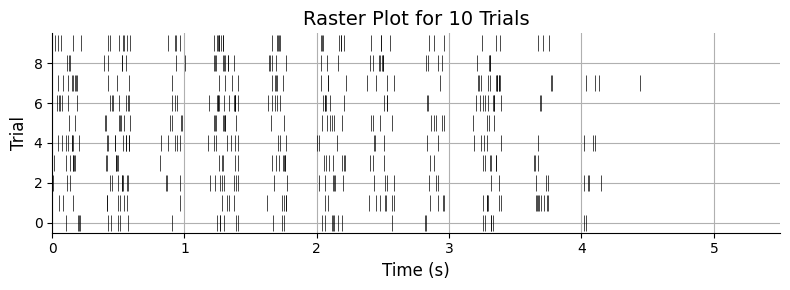

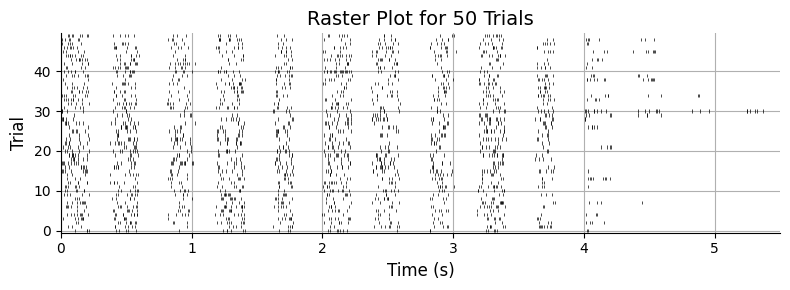

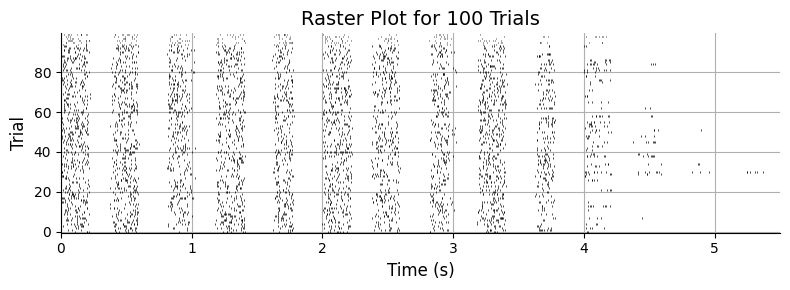

In [3]:
def raster_plot(trial_length, spike_matrix, num_trials=100):
        _, ax = plt.subplots(figsize=(8, 3))
    
        # eventplot expect a list of array, one array per row/trial
        spike_list = []
        for trial in range(num_trials):
            spikes = spike_matrix[:, trial]  # Extract spike times for the current trial
            spikes = spikes[~np.isnan(spikes)] # Remove NaN values
            spike_list.append(spikes)  # Append valid spike times to the list
    
        # Eventplot
        ax.eventplot(spike_list, colors='black', linelengths=0.8, linewidths=0.5)
        ax.set_xlim(0, trial_length)
        ax.set_ylim(-0.5, num_trials - 0.5)
        ax.set_xlabel("Time (s)", fontsize=12)
        ax.set_ylabel("Trial", fontsize=12)
        ax.set_title(f"Raster Plot for {num_trials} Trials", fontsize=14)
        sns.despine()
        plt.grid()
        plt.tight_layout()
        plt.show()

raster_plot(trial_length=T, spike_matrix=spike_data_in_s, num_trials=10)
raster_plot(trial_length=T, spike_matrix=spike_data_in_s, num_trials=50)
raster_plot(trial_length=T, spike_matrix=spike_data_in_s, num_trials=100)

(b) Calculate and plot the trial-averaged firing rate using a sliding rectangular window with a width of 30, 90, and
200 ms. Compute the trial-averaged response function first and then convolve it with the rectangular window.


(c) Include different numbers of trials (10, 50, 100). Comment on your results.

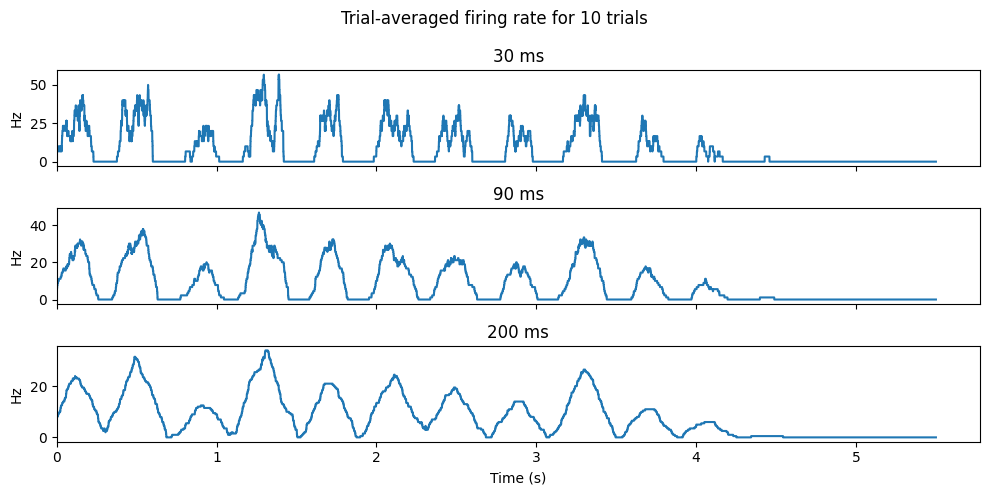

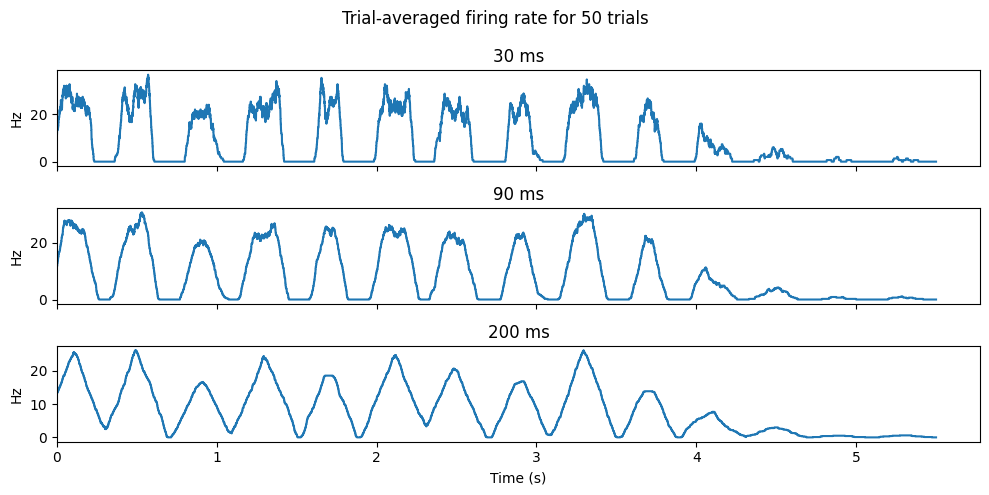

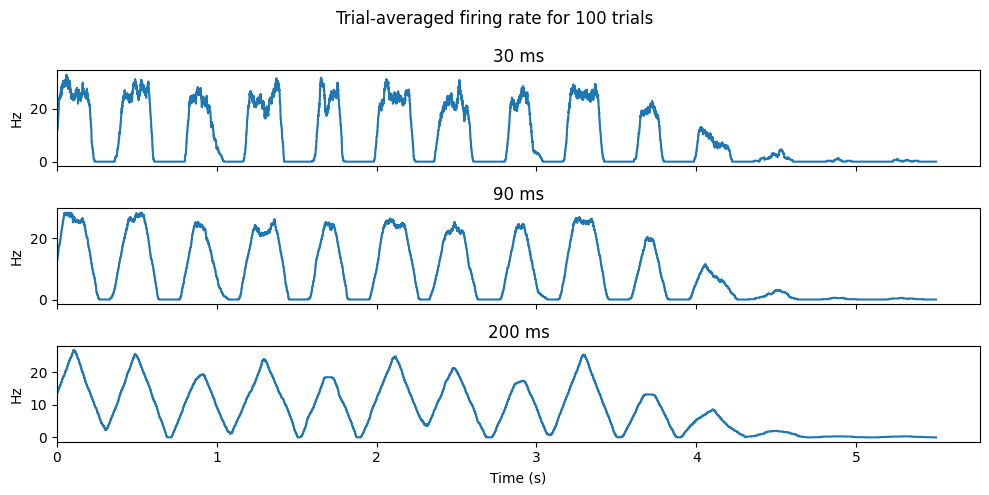

In [4]:
##convert spike times (list of events) to spike trains (time series, sampled at dt)
# to have a function over time, as needed for convolution

def plot_convolution(trials, width, dt):
    for n_trial in trials:
        spike_trains = np.zeros((n_trial, n_time)) #binary raster representation of spikes

        for trial in range(n_trial):
            spikes = spike_data_in_s[:, trial]
            
            # remove NaNs
            spikes = spikes[~np.isnan(spikes)]
            
            # convert to indices
            indices = (spikes / dt).astype(int)
            
            # safety: remove out-of-bounds
            indices = indices[indices < n_time]
            
            spike_trains[trial, indices] = 1
            
        trial_avg = np.mean(spike_trains, axis=0)

        ## Convolution with rectangular window
        rates = {}

        for w in width:
            bins = int(w / dt)
            
            # rectangular kernel
            kernel = np.ones(bins) / (bins * dt)
            
            rate = np.convolve(trial_avg, kernel, mode='same')
            rates[w] = rate

        # Plotting
        time_axis = np.arange(0, T, dt)

        fig, axes = plt.subplots(len(width), 1, sharex=True, figsize=(10, 5))

        for i, w in enumerate(width):
            axes[i].plot(time_axis, rates[w])
            axes[i].set_ylabel("Hz")
            axes[i].set_xlim(0)
            axes[i].set_title(f"{int(w*1000)} ms")

        axes[-1].set_xlabel("Time (s)")
        fig.suptitle(f"Trial-averaged firing rate for {n_trial} trials")

        plt.tight_layout()
        plt.show()
        
plot_convolution(trials=[10, 50, 100], width = [0.03, 0.09, 0.200], dt=dt)

Interpretation: 
- With only 10 trials, random variability between trials is large, so the average is noisy. With more trials, the noise averages out and the underlying firing rate structure becomes clearer (smoother function).
- A narrower window does less temporal averaging, following transient fluctuations are visible. That means the fine temporal structure of the response is visible, i.e. the function has more smaller up-and-downs. A wider window blurs those details but gives a more stable, less noisy estimate of the rate. -->  tradeoff: narrow windows = low bias (captures true shape) but high variance (noisy); wide windows = low variance (smooth) but high bias (smears out sharp features). 

### 2. Spike-Triggered Average (3 points)

- load STA data.mat with the scipy.io function loadmat 
- file contains the stimulus vector and the spikes times of a model neuron that was exposed to the stimulus for 100 trials. The trial length is T = 1 s, the time resolution is 0.1 ms



In [5]:
# Stimulus: continuous signal over time (1D array)
# SpikeTimes: 2D matrix (trials × spikes), each row contains spike times for a trial
        
STA_data = scipy.io.loadmat("Week2\STA_data.mat")
STA_T = 1 # in seconds
STA_dt = 0.0001 # in seconds 
STA_spike_times = STA_data["SpikeTimes"] # in seconds
STA_stimulus = STA_data["Stimulus"].flatten() # flatten to 1D array

Calculate the spike-triggered average

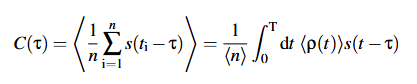

- s(t) is the stimulus
- ρ(t) is the neural response function (angular brackets denote trial averages) 

To compute there are two methods: 
-  loop over the spike times $t_i$ (first expression) 
- use the numpy function correlate (second expression)

Which one is more efficient?





In [6]:
tau = 0.05 # in seconds, time window for STA (50 ms)

In [7]:
# STA using an loop over spikes
# For each spike, we extract the stimulus segment preceding it and accumulate
# The result is averaged over all spikes and gives the average stimulus leading to a spike

# Convert tau from 50ms (0.05s) to number of time steps
steps = int(tau/ STA_dt)

sta_loop = np.zeros(steps)
n_spikes = 0

# Loop through trials
for trial in range(STA_spike_times.shape[0]):
    spikes = STA_spike_times[trial]
    spikes = spikes[~np.isnan(spikes)]  # Remove NaNs from spike list
    
    # Loop through spikes for this trial
    for spike_time in spikes:
        spike_idx = int(spike_time / STA_dt)  # Convert to index
        if steps <= spike_idx < len(STA_stimulus):
            # Accumulate the stimulus window before the spike
            sta_loop += STA_stimulus[spike_idx - steps:spike_idx]
            n_spikes += 1

sta_loop = sta_loop / n_spikes 


In [8]:
# use cross-correlation between the stimulus and the spike train to compute STA

# time-aligned spike density vector (rho) across all trials
# correlate rho with the stimulus and extract the segment before zero 

# Initialize firing rate vector aligned with stimulus
rho = np.zeros_like(STA_stimulus)
for trial in range(STA_spike_times.shape[0]):
    spikes = STA_spike_times[trial]
    spikes = spikes[~np.isnan(spikes)]
    for spike_time in spikes:
        idx = int(spike_time / STA_dt)
        if idx < len(rho):
            rho[idx] += 1

# Compute full cross-correlation between spike train and stimulus
full_corr = np.correlate(rho, STA_stimulus, mode="full")
lag_zero = len(STA_stimulus) - 1

# Extract the STA segment from the correlation result
corr_sta = full_corr[lag_zero - steps : lag_zero]

corr_sta = corr_sta / int(np.sum(rho))


More efficient is the correlate method, as process the entire signal as once.

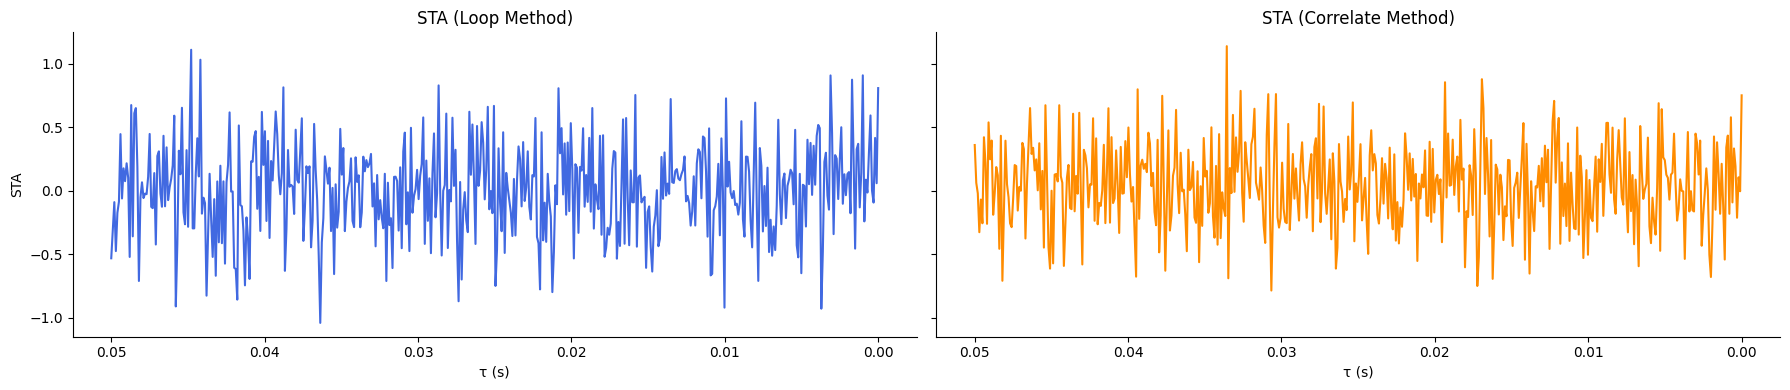

In [9]:
tau_axis = np.linspace(0.05, 0, int(0.050 /STA_dt))  # τ = time before spike
 
fig, axs = plt.subplots(1, 2, figsize=(18, 4), sharey=True)
# Plot 1: Loop method
axs[0].plot(tau_axis, sta_loop[::-1], color='royalblue')
axs[0].set_title("STA (Loop Method)")
axs[0].invert_xaxis()
axs[0].set_xlabel("τ (s)")
axs[0].set_ylabel("STA")

# Plot 2: Correlate method
axs[1].plot(tau_axis, corr_sta[::-1], color='darkorange')
axs[1].set_title("STA (Correlate Method)")
axs[1].invert_xaxis()
axs[1].set_xlabel("τ (s)")

sns.despine()
plt.tight_layout()
plt.show()

Plot the spike-triggered average for 0 ≤ τ ≤ 50 ms. 
Ensure  STA is plotted according to the convention: 
- τ positive and decreasing from left to right
